# Model evaluation

Compare every model in the registry (`ml/experiments.py`) on the same held-out test period, then dig into one.

- Each model is trained on data **before** `config.TEST_START` and tested on everything **after** it, which is data it never saw.
- Results live in `models/experiments/<name>/`. This notebook only *reads* them, except for the optional "run" cell.
- The same thing from the terminal: `python -m ml.evaluate compare | show <name> | replay <name> <day>`.

**To add a model:** add an entry to `EXPERIMENTS` in `ml/experiments.py`, put its name in `RUN_MODELS` below, set `RUN = True`, and run all cells.

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "ml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve

from ml import config
from ml.evaluate import load_metrics, run, score
from ml.experiments import EXPERIMENTS
from ml.plotting import GRAY, SEQ_CMAP, SERIES, TEXT_2, setup, show

setup()
pd.set_option("display.width", 160)
EXP_DIR = config.EXPERIMENTS_DIR

# Each model keeps the same color in every chart: production model first (blue),
# main baseline second (orange); anything else takes the next free slot.
_FIXED = ["hgb_full", "baseline_line_hour", "hgb_calendar", "logreg_full"]
_ORDER = _FIXED + [n for n in EXPERIMENTS if n not in _FIXED]

def color(name):
    return SERIES[_ORDER.index(name) % len(SERIES)] if name in _ORDER else GRAY

## 1. (Optional) train and test models
Skip this if the models are already saved. Takes ~15s per model.

In [2]:
RUN = False
RUN_MODELS = ["hgb_full"]          # or list(EXPERIMENTS) for everything

if RUN:
    run(RUN_MODELS, config.TEST_START)

runs = load_metrics()
for name, exp in EXPERIMENTS.items():
    print(f"  [{'saved' if name in runs else '     '}] {name:<20} {exp.description}")

  [saved] baseline_overall     Always predicts the average delay rate for that line
  [saved] baseline_line_hour   Historical rate for this line at this hour of this weekday
  [saved] hgb_calendar         Gradient boosting on line + calendar only (no weather, no recent delays)
  [saved] hgb_no_lags          Gradient boosting without recent-delay features
  [saved] hgb_full             Gradient boosting on all features (current production model)
  [saved] logreg_full          Logistic regression on all features


## 2. Leaderboard

Higher is better for every metric. Scores are on the test period from `2025-08-01` (1,191,168 predictions, delay rate 18.8%).

| metric | what it means | random guessing | simple baseline (`baseline_line_hour`) | `hgb_full` | perfect |
|---|---|---|---|---|---|
| **roc_auc** | Does it rank delayed hours above quiet ones? | 0.500 | 0.709 | 0.730 | 1.000 |
| **pr_auc** | Same, but focused on the delayed hours | 0.188 (the delay rate) | 0.321 | 0.351 | 1.000 |
| **brier_skill** | How much more accurate its %s are than always guessing the average | 0.000 | 0.076 | 0.098 | 1.000 |
| **high_prec** | Of hours flagged "high risk" (p ≥ 0.35), the share that actually had a delay | 0.188 | 0.413 | 0.417 | 1.000 |
| **high_recall** | Of all delays, the share we flagged "high risk" (p ≥ 0.35) | 0.000 if it never flags; otherwise equals the share of hours flagged | 0.056 | 0.183 | 1.000 |

The baseline and `hgb_full` columns are copied from the output below. If you retrain, update them.

,roc_auc,pr_auc,brier_skill,high_prec,high_recall,test_from
hgb_full,0.7297,0.3509,0.0976,0.417,0.1826,2025-08-01
hgb_calendar,0.7143,0.3265,0.0796,0.4134,0.0604,2025-08-01
baseline_line_hour,0.7089,0.3212,0.0762,0.4127,0.0563,2025-08-01
hgb_no_lags,0.7079,0.3177,0.0754,0.3871,0.0869,2025-08-01
logreg_full,0.704,0.3299,0.0765,0.4077,0.1527,2025-08-01
baseline_overall,0.6507,0.2778,0.0392,None,0.0,2025-08-01


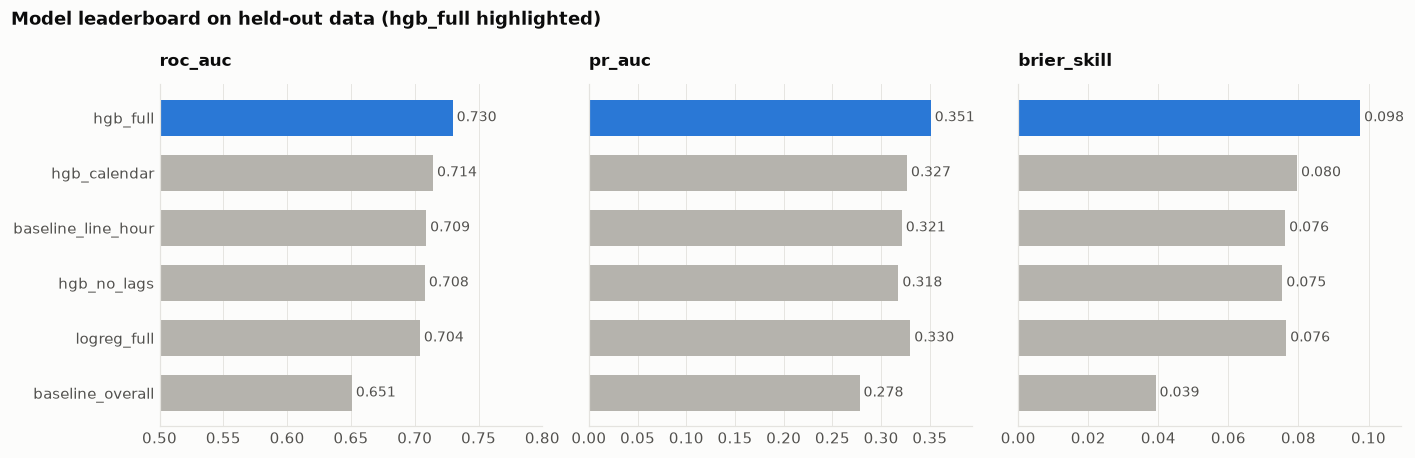

In [3]:
FOCUS = "hgb_full"         # the model the detailed charts below are about
BASELINE = "baseline_line_hour"

board = pd.DataFrame({
    name: {
        "roc_auc": m["overall"]["roc_auc"],
        "pr_auc": m["overall"]["pr_auc"],
        "brier_skill": m["overall"]["brier_skill"],
        "high_prec": m["overall"]["high_precision"],
        "high_recall": m["overall"]["high_recall"],
        "test_from": m["test_period"][0][:10],
    }
    for name, m in runs.items()
}).T.sort_values("roc_auc", ascending=False)
display(board)

metrics = ["roc_auc", "pr_auc", "brier_skill"]
fig, axes = plt.subplots(1, 3, figsize=(13, 0.45 * len(board) + 1.5), sharey=True)
order = board.sort_values("roc_auc").index
for ax, m in zip(axes, metrics):
    vals = board.loc[order, m].astype(float).fillna(0)
    ax.barh(order, vals, color=[SERIES[0] if n == FOCUS else GRAY for n in order], height=0.65)
    lo = 0.5 if m == "roc_auc" else 0
    ax.set_xlim(lo, vals.max() * 1.12 if m != "roc_auc" else max(vals.max() + 0.03, 0.8))
    for y, v in enumerate(vals):
        ax.text(v, y, f" {v:.3f}", va="center", fontsize=9, color=TEXT_2)
    ax.set_title(m, fontsize=11)
    ax.grid(axis="y", visible=False)
fig.suptitle(f"Model leaderboard on held-out data ({FOCUS} highlighted)", x=0.01, ha="left", fontweight="bold")
show(fig, "eval_leaderboard")

## 3. Load holdout predictions
Every prediction each model made on the test period (one row per line x hour x hours-ahead).

In [4]:
COMPARE = [n for n in ["baseline_line_hour", "hgb_calendar", "logreg_full", "hgb_full"] if n in runs]

preds = {n: pd.read_parquet(EXP_DIR / n / "test_predictions.parquet") for n in COMPARE}
y = preds[COMPARE[0]]["label"].to_numpy()
print(f"{len(y):,} test predictions per model, delay rate {y.mean():.1%}")

1,191,168 test predictions per model, delay rate 18.8%


## 4. ROC and precision-recall curves
The further up-left (ROC) or up-right (PR) the curve, the better. Gray = random guessing.

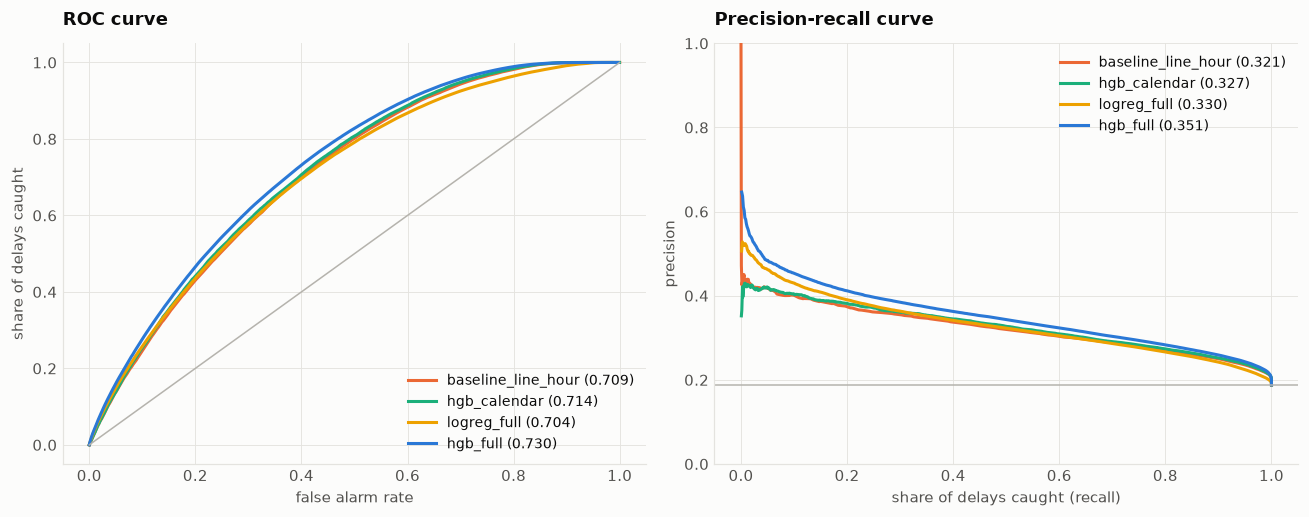

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
for n in COMPARE:
    p = preds[n]["p"].to_numpy()
    fpr, tpr, _ = roc_curve(y, p)
    prec, rec, _ = precision_recall_curve(y, p)
    step = max(1, len(fpr) // 2000)
    a1.plot(fpr[::step], tpr[::step], color=color(n), label=f"{n} ({runs[n]['overall']['roc_auc']:.3f})")
    step = max(1, len(rec) // 2000)
    a2.plot(rec[::step], prec[::step], color=color(n), label=f"{n} ({runs[n]['overall']['pr_auc']:.3f})")
a1.plot([0, 1], [0, 1], color=GRAY, linewidth=1)
a2.axhline(y.mean(), color=GRAY, linewidth=1)
a1.set(xlabel="false alarm rate", ylabel="share of delays caught", title="ROC curve")
a2.set(xlabel="share of delays caught (recall)", ylabel="precision", title="Precision-recall curve", ylim=(0, 1))
a1.legend(loc="lower right", fontsize=9); a2.legend(loc="upper right", fontsize=9)
show(fig, "eval_curves")

## 5. How far ahead can we see?
Accuracy for each forecast horizon. Recent-delay features should matter most at +1h.

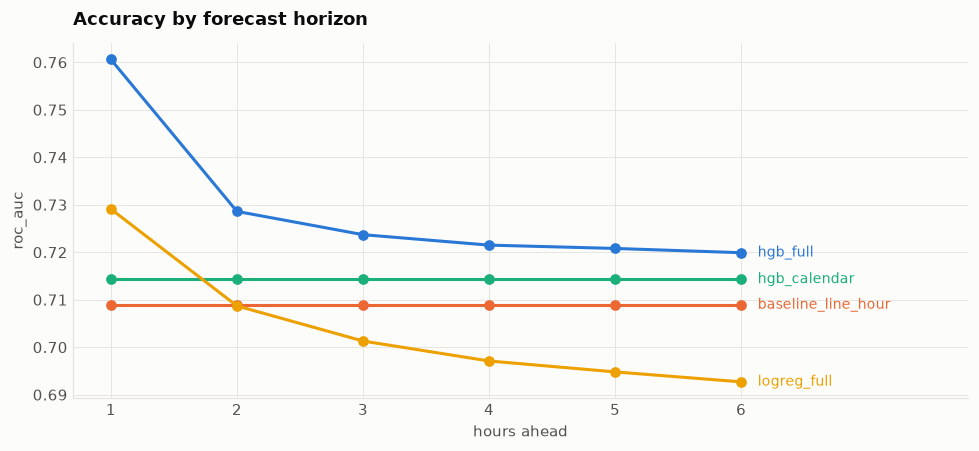

,baseline_line_hour,hgb_calendar,logreg_full,hgb_full
+1h,0.709,0.714,0.729,0.761
+2h,0.709,0.714,0.709,0.729
+3h,0.709,0.714,0.701,0.724
+4h,0.709,0.714,0.697,0.722
+5h,0.709,0.714,0.695,0.721
+6h,0.709,0.714,0.693,0.720


In [6]:
fig, ax = plt.subplots()
tbl = {}
for n in COMPARE:
    bh = runs[n]["by_horizon"]
    hs = sorted(int(h) for h in bh)
    vals = [bh[str(h)]["roc_auc"] for h in hs]
    tbl[n] = vals
    ax.plot(hs, vals, color=color(n), marker="o")
    ax.text(hs[-1] + 0.1, vals[-1], f" {n}", color=color(n), va="center", fontsize=9)
ax.set(xlabel="hours ahead", ylabel="roc_auc", title="Accuracy by forecast horizon")
ax.set_xticks(hs)
ax.set_xlim(hs[0] - 0.3, hs[-1] + 1.8)
show(fig, "eval_by_horizon")
pd.DataFrame(tbl, index=[f"+{h}h" for h in hs]).round(3)

## 6. Calibration: can you trust the percentages?
When the model says 30%, did delays happen ~30% of the time? Points on the gray diagonal = perfectly calibrated.

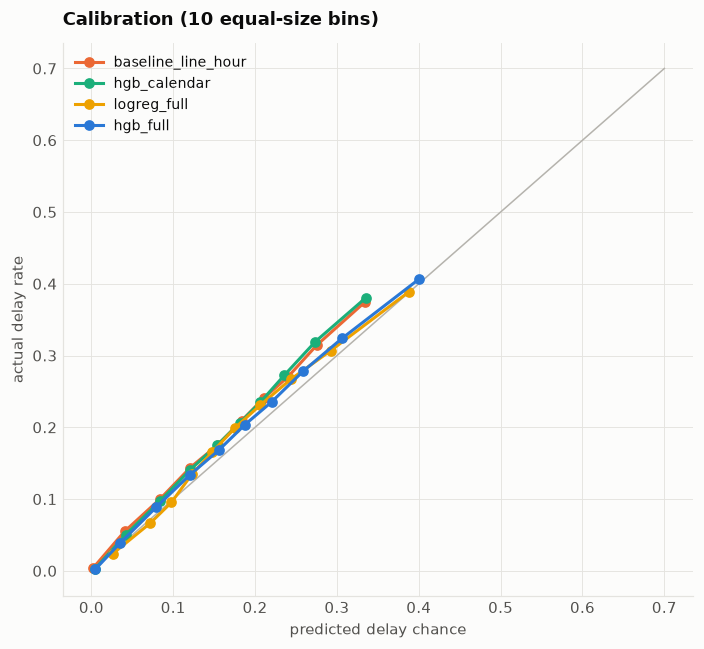

,n,predicted,actual
0,119117,0.0048,0.0023
1,119117,0.0348,0.0384
2,119117,0.0793,0.0888
3,119116,0.1200,0.1334
4,119117,0.1554,0.1679
5,119117,0.1876,0.2037
6,119116,0.2204,0.2356
7,119117,0.2587,0.2782
8,119117,0.3061,0.3238
9,119117,0.3998,0.4061


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 0.7], [0, 0.7], color=GRAY, linewidth=1)
for n in COMPARE:
    cal = pd.DataFrame(runs[n]["calibration"])
    ax.plot(cal["predicted"], cal["actual"], color=color(n), marker="o", label=n)
ax.set(xlabel="predicted delay chance", ylabel="actual delay rate", title="Calibration (10 equal-size bins)")
ax.legend(loc="upper left", fontsize=9)
show(fig, "eval_calibration")
pd.DataFrame(runs[FOCUS]["calibration"])

## 7. Threshold explorer
The app calls a prediction "high risk" at `config.RISK_HIGH` and "medium" at `config.RISK_MEDIUM`. This shows the trade-off: a lower threshold catches more delays but raises more false alarms.

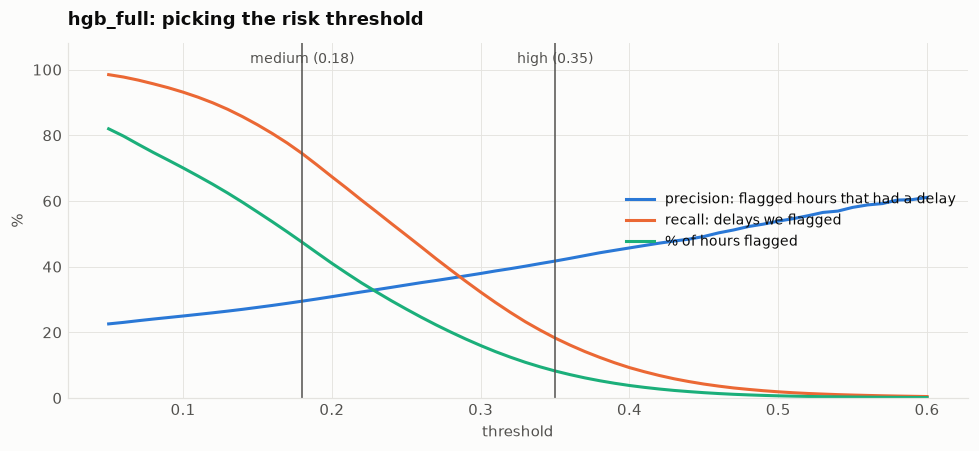

In [8]:
p = preds[FOCUS]["p"].to_numpy()
ts = np.linspace(0.05, 0.6, 56)
prec = [y[p >= t].mean() if (p >= t).any() else np.nan for t in ts]
rec = [(p[y == 1] >= t).mean() for t in ts]
flag = [(p >= t).mean() for t in ts]

fig, ax = plt.subplots()
ax.plot(ts, np.array(prec) * 100, color=SERIES[0], label="precision: flagged hours that had a delay")
ax.plot(ts, np.array(rec) * 100, color=SERIES[1], label="recall: delays we flagged")
ax.plot(ts, np.array(flag) * 100, color=SERIES[2], label="% of hours flagged")
for t, name in [(config.RISK_MEDIUM, "medium"), (config.RISK_HIGH, "high")]:
    ax.axvline(t, color=TEXT_2, linewidth=1)
    ax.text(t, 102, f"{name} ({t})", ha="center", fontsize=9, color=TEXT_2)
ax.set(xlabel="threshold", ylabel="%", ylim=(0, 108), title=f"{FOCUS}: picking the risk threshold")
ax.legend(loc="center right", fontsize=9)
show(fig, "eval_thresholds")

## 8. Where is the model weak?
Accuracy for different situations, compared with the simple baseline.

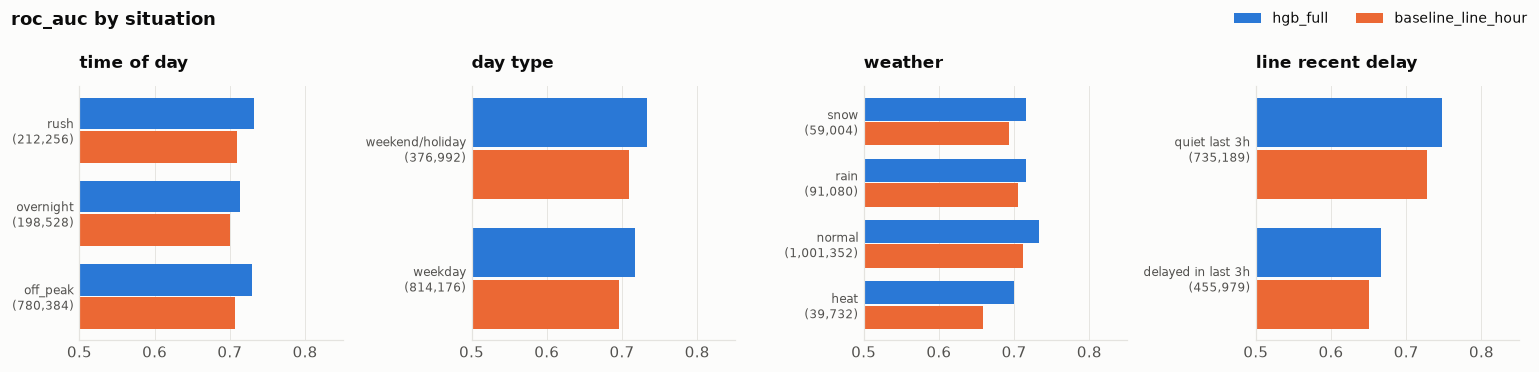

,segment,group,n,delay_rate,hgb_full_auc,baseline_line_hour_auc
0,time_of_day,off_peak,780384,0.199,0.729,0.707
1,time_of_day,overnight,198528,0.156,0.714,0.700
2,time_of_day,rush,212256,0.178,0.732,0.710
3,day_type,weekday,814176,0.211,0.717,0.696
4,day_type,weekend/holiday,376992,0.138,0.734,0.710
5,weather,heat,39732,0.211,0.700,0.658
6,weather,normal,1001352,0.185,0.733,0.712
7,weather,rain,91080,0.210,0.715,0.705
8,weather,snow,59004,0.192,0.716,0.694
9,line_recent_delay,delayed in last 3h,455979,0.258,0.667,0.650


In [9]:
segs = runs[FOCUS]["by_segment"]
fig, axes = plt.subplots(1, len(segs), figsize=(14, 3.4), sharex=True)
rows = []
for ax, (seg, parts) in zip(axes, segs.items()):
    names = list(parts)
    yy = np.arange(len(names))
    focus = [parts[k]["roc_auc"] for k in names]
    base = [runs[BASELINE]["by_segment"][seg][k]["roc_auc"] for k in names]
    ax.barh(yy + 0.2, focus, height=0.38, color=color(FOCUS), label=FOCUS)
    ax.barh(yy - 0.2, base, height=0.38, color=color(BASELINE), label=BASELINE)
    ax.set_yticks(yy, [f"{k}\n({parts[k]['n']:,})" for k in names], fontsize=8)
    ax.set_xlim(0.5, 0.85)
    ax.set_title(seg.replace("_", " "), fontsize=11)
    ax.grid(axis="y", visible=False)
    rows += [{"segment": seg, "group": k, "n": parts[k]["n"], "delay_rate": parts[k]["delay_rate"],
              f"{FOCUS}_auc": f, f"{BASELINE}_auc": b} for k, f, b in zip(names, focus, base)]
fig.suptitle("roc_auc by situation", x=0.01, ha="left", fontweight="bold")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, fontsize=9)
show(fig, "eval_segments")
pd.DataFrame(rows).round(3)

## 9. Accuracy per line

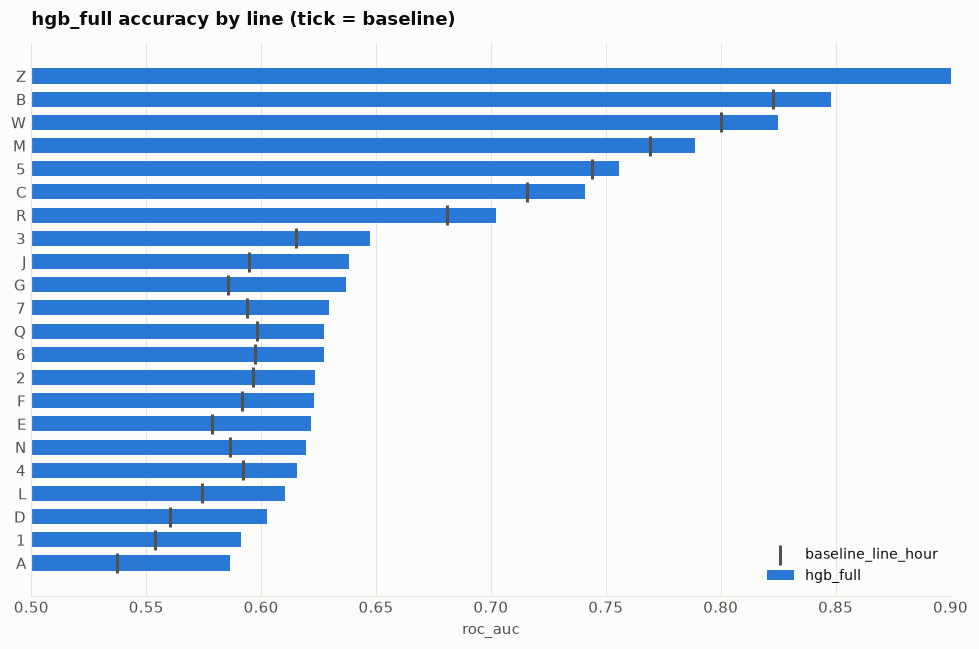

,n,delay_rate,roc_auc,pr_auc,brier_skill,baseline_auc
line,,,,,,
A,54144.0,0.373,0.586,0.444,0.017,0.537
1,54144.0,0.167,0.591,0.219,0.014,0.554
D,54144.0,0.269,0.603,0.352,0.025,0.560
L,54144.0,0.120,0.611,0.174,0.015,0.574
4,54144.0,0.232,0.616,0.324,0.032,0.592
N,54144.0,0.256,0.620,0.355,0.037,0.587
E,54144.0,0.216,0.622,0.307,0.033,0.579
F,54144.0,0.311,0.623,0.409,0.038,0.592
2,54144.0,0.284,0.624,0.386,0.040,0.596


In [10]:
bl = pd.read_csv(EXP_DIR / FOCUS / "by_line.csv", index_col="line").sort_values("roc_auc")
bb = pd.read_csv(EXP_DIR / BASELINE / "by_line.csv", index_col="line").reindex(bl.index)
fig, ax = plt.subplots(figsize=(9, 6))
yy = np.arange(len(bl))
ax.barh(yy, bl["roc_auc"], color=color(FOCUS), height=0.65, label=FOCUS)
ax.scatter(bb["roc_auc"], yy, color=TEXT_2, marker="|", s=160, linewidths=2, zorder=3, label=BASELINE)
ax.set_yticks(yy, bl.index)
ax.set_xlim(0.5, 0.9)
ax.set(xlabel="roc_auc", title=f"{FOCUS} accuracy by line (tick = baseline)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=9)
show(fig, "eval_by_line")
bl[["n", "delay_rate", "roc_auc", "pr_auc", "brier_skill"]].assign(baseline_auc=bb["roc_auc"]).round(3)

## 10. Replay a day
What the model predicted (1h ahead) for every line and hour, with dots where a delay **actually** happened. Good predictions = dots on dark cells.

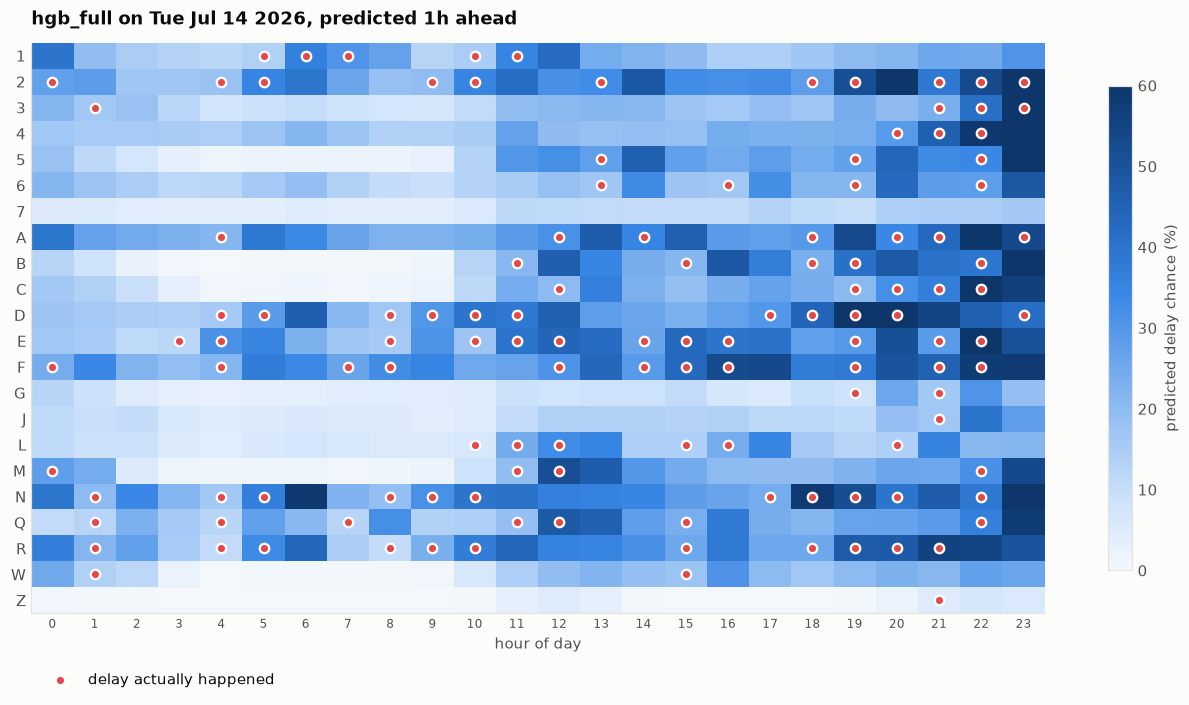

126 delayed line-hours out of 528; roc_auc that day = 0.7274


In [11]:
DAY = "2026-07-14"
HORIZON = 1

df = preds[FOCUS]
d = df[(df["target_ts"].dt.normalize() == pd.Timestamp(DAY)) & (df["horizon"] == HORIZON)]
d = d.assign(hour=d["target_ts"].dt.hour, line=d["line"].astype(str))
grid_p = d.pivot(index="line", columns="hour", values="p").reindex(config.LINES)
grid_y = d.pivot(index="line", columns="hour", values="label").reindex(config.LINES)

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(grid_p.values * 100, cmap=SEQ_CMAP, aspect="auto", vmin=0, vmax=60)
yy, xx = np.nonzero(grid_y.values == 1)
ax.scatter(xx, yy, s=38, color="#e34948", edgecolors="white", linewidths=1.5, label="delay actually happened")
ax.set_yticks(range(len(grid_p)), grid_p.index)
ax.set_xticks(range(24), [f"{h}" for h in range(24)], fontsize=8)
ax.set_xlabel("hour of day")
ax.grid(False)
ax.set_title(f"{FOCUS} on {pd.Timestamp(DAY):%a %b %d %Y}, predicted {HORIZON}h ahead")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), frameon=False)
fig.colorbar(im, ax=ax, label="predicted delay chance (%)", shrink=0.85)
show(fig, "eval_replay")
s = score(d["label"], d["p"])
print(f"{int(d['label'].sum())} delayed line-hours out of {len(d)}; roc_auc that day = {s['roc_auc']}")

## 11. What does the model rely on?
Permutation importance: shuffle one input at a time and measure how much accuracy drops. Bigger drop = more important. Uses a 60k-row sample of the test period and takes ~30s.

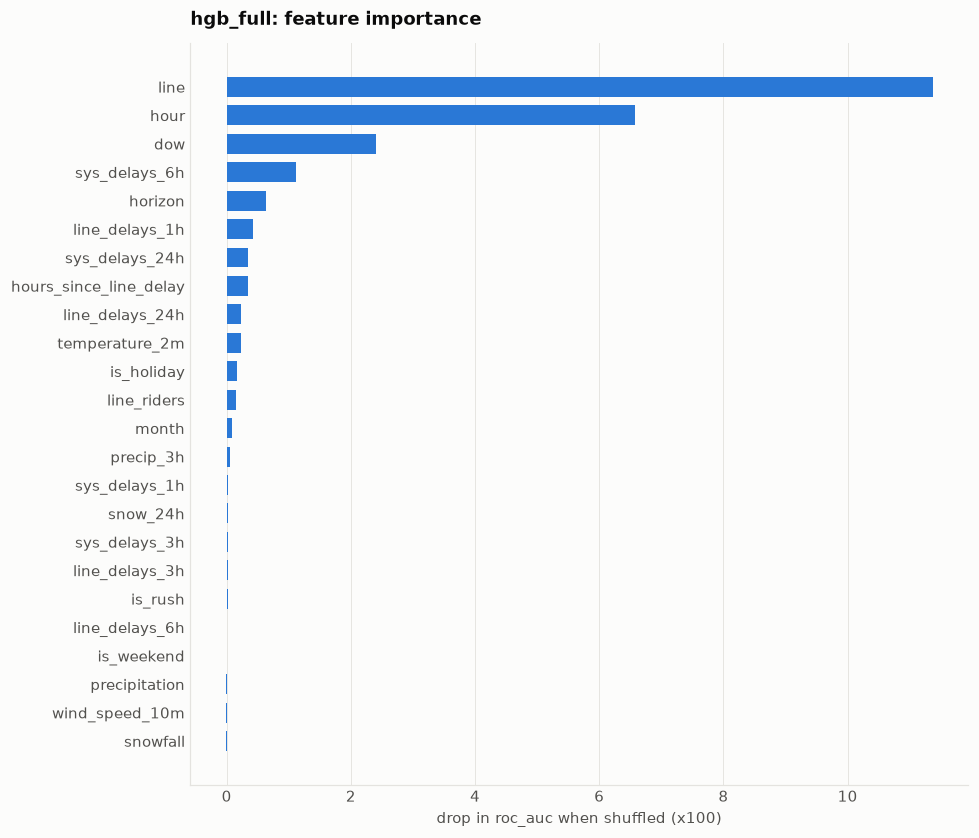

,auc_drop_x100
line,11.37
hour,6.58
dow,2.41
sys_delays_6h,1.11
horizon,0.63
line_delays_1h,0.42
sys_delays_24h,0.35
hours_since_line_delay,0.35
line_delays_24h,0.23
temperature_2m,0.23


In [12]:
import joblib
from sklearn.inspection import permutation_importance
from ml.dataset import evaluation_rows, load_data

bundle = joblib.load(EXP_DIR / FOCUS / "model.joblib")
sample = evaluation_rows(load_data(), start=config.TEST_START).sample(60_000, random_state=0)
imp = permutation_importance(bundle["model"], sample[bundle["features"]], sample["label"],
                             scoring="roc_auc", n_repeats=3, random_state=0, n_jobs=-1)
imp = pd.Series(imp.importances_mean, bundle["features"]).sort_values()

fig, ax = plt.subplots(figsize=(9, 0.28 * len(imp) + 1))
ax.barh(imp.index, imp.values * 100, color=SERIES[0], height=0.7)
ax.set(xlabel="drop in roc_auc when shuffled (x100)", title=f"{FOCUS}: feature importance")
ax.grid(axis="y", visible=False)
show(fig, "eval_importance")
(imp[::-1] * 100).round(2).rename("auc_drop_x100").to_frame()